In [ ]:
import os
import re
from io import StringIO
from pathlib import Path
import gc 

import anndata as ad
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import math

import cell2location
from cell2location.utils import select_slide
from cell2location.plt import plot_spatial
from cell2location.utils.filtering import filter_genes
from cell2location.models import RegressionModel, Cell2location
import torch

import matplotlib.cm as cm
import networkx as nx

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Plotting

In [ ]:
adata_vis = sc.read_h5ad(os.path.join(run_name, "sp_batch{}.h5ad".format(clone)))

In [ ]:
from matplotlib.colors import ListedColormap

# Helpful slide selection function
def select_slide_sp(adata, s, s_col='sample'):
    r""" Select data for one slide from the spatial anndata object.

    :param adata: Anndata object with multiple spatial samples
    :param s: name of selected sample
    :param s_col: column in adata.obs listing sample name for each location
    """

    slide = adata[adata.obs[s_col].isin([s]), :]
    s_keys = list(slide.uns['spatial'].keys())
    s_spatial = np.array(s_keys)[[s in k for k in s_keys]][0]

    slide.uns['spatial'] = {s_spatial: slide.uns['spatial'][s_spatial]}

    return slide

def create_colormap(R, G, B):
        spacing = int(20 * 2.55)

        N = 255
        M = 3

        alphas = np.concatenate([[0] * spacing * M, np.linspace(0, 1.0, (N - spacing) * M)])

        vals = np.ones((N * M, 4))
        #         vals[:, 0] = np.linspace(1, R / 255, N * M)
        #         vals[:, 1] = np.linspace(1, G / 255, N * M)
        #         vals[:, 2] = np.linspace(1, B / 255, N * M)
        for i, color in enumerate([R, G, B]):
            vals[:, i] = color / 255
        vals[:, 3] = alphas

        return ListedColormap(vals)

In [ ]:
annotation = {
    0:'Cycling',
    1:'NPC-neuronal-like 1',
    2:'Gliosis-hypoxia',
    3:'AC-gliosis-like 2',
    4:'NPC-OPC-like 2', # oligo-like
    5:'AC-gliosis-like 1',
    6:'NPC-neuronal-like 2',
    7:'NPC-OPC-like 1',
    8:'AC-NPC-OPC-like', # (NPC-neuronal)
    9:'AC-progenitor-like',  
    10:'NPC-neuronal-like 3', 
    11:'OPC-like', # (NPC-OPC)
}

In [ ]:
clone = 'at15_4'

In [ ]:
wd = '../data/cell2fate_trajectories/'
label_annotation = pd.read_csv(os.path.join(wd, "all_top_genes_labelled.csv"), index_col=0)[['label']]
label_annotation['annotation'] = [annotation[i] for i in label_annotation['label']]
label_annotation = label_annotation[label_annotation.index.str.contains(clone, case=False)]
label_annotation['Module'] = ['Module '+str(re.sub('^.*_', '', i)) for i in label_annotation.index]

In [ ]:
labels = adata_vis.uns['mod']['factor_names']
adata_vis.obs[labels] = adata_vis.obsm['q05_cell_abundance_w_sf']

In [ ]:
for i in set(label_annotation['annotation']):
    modules = list(set(label_annotation[label_annotation['annotation']==i]['Module']))
    adata_vis.obs[i] = adata_vis.obs[modules].sum(axis=1)

In [ ]:
set(label_annotation['annotation'])

{'AC-NPC-OPC-like',
 'AC-gliosis-like 1',
 'AC-gliosis-like 2',
 'Cycling',
 'Gliosis-hypoxia',
 'NPC-OPC-like 1',
 'NPC-OPC-like 2',
 'NPC-neuronal-like 1',
 'NPC-neuronal-like 2',
 'NPC-neuronal-like 3'}

In [ ]:
from matplotlib.colors import to_rgb

color_dict = {
 'Cycling': '#ffd92f',
 'NPC-neuronal-like 1': '#e377c2',
 'Gliosis-hypoxia': '#ff7f0e',
 'AC-gliosis-like 2': '#d62728',
 'NPC-OPC-like 2': '#bcbd22',
 'AC-gliosis-like 1': '#8c564b',
 'NPC-neuronal-like 2': '#5A14A5',
 'NPC-OPC-like 1': '#2ca02c',
 'AC-NPC-OPC-like 1': '#7f7f7f',
 'AC-progenitor-like': '#003f5c',
 'NPC-neuronal-like 3': '#ff1493',  # bright magenta
 'OPC-like': '#00bfff'              # bright sky blue
}


clust_dict = {}
for k in color_dict:
    r,g,b = to_rgb(color_dict[k])
    rgb = [int(x * 255) for x in (r, g, b)]
    clust_dict[k] = create_colormap(rgb[0], rgb[1], rgb[2])

In [ ]:
outdir = '../data/trajectories/plots/'

[<matplotlib.colors.ListedColormap object at 0x147ff356ada0>, <matplotlib.colors.ListedColormap object at 0x147ff3568e20>, <matplotlib.colors.ListedColormap object at 0x147ff354b580>, <matplotlib.colors.ListedColormap object at 0x147ff354b370>, <matplotlib.colors.ListedColormap object at 0x147ff356b8e0>]


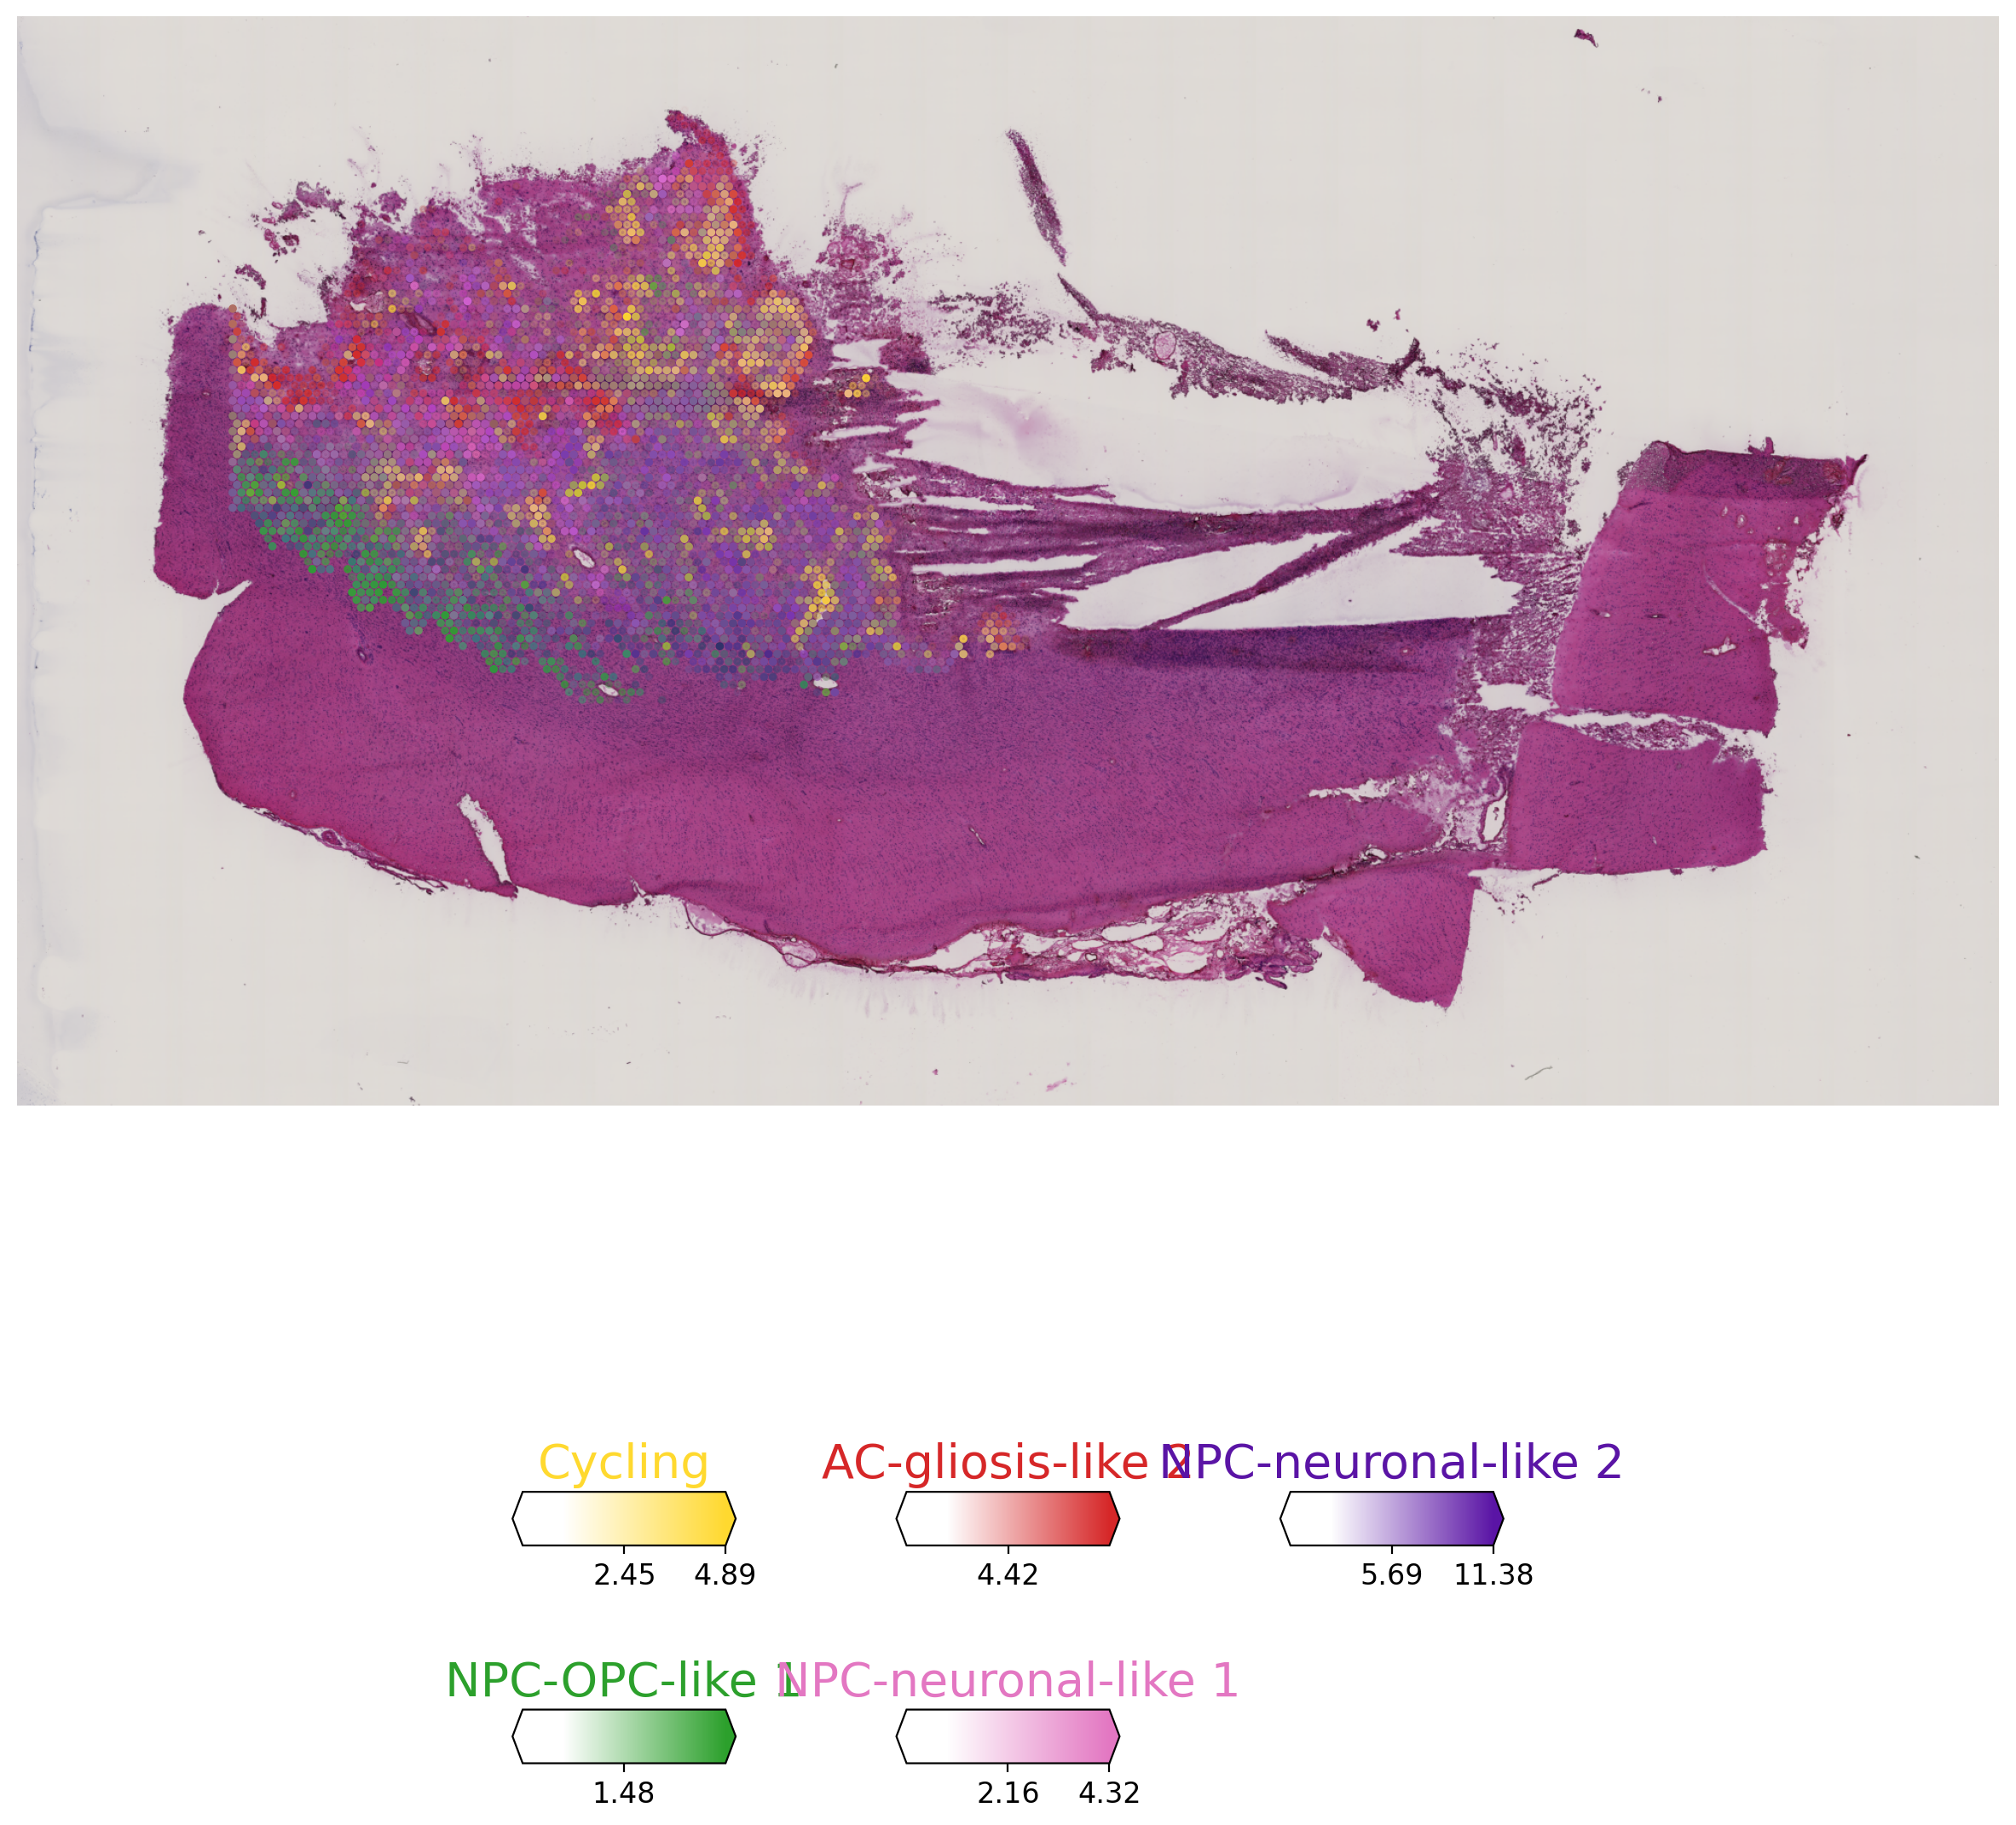

In [ ]:
clust_labels = ['Cycling',  
                'AC-gliosis-like 2',
                'NPC-neuronal-like 2',
                'NPC-OPC-like 1',
                'NPC-neuronal-like 1'
]
clust_col = ['' + str(i) for i in clust_labels] # in case column names differ from labels

with mpl.rc_context({'figure.figsize': (15, 15)}):
        fig = plot_spatial(
            adata=adata_vis,
            color=clust_col, labels=clust_col,
            show_img=True,
            style='fast',
            max_color_quantile=0.95,
            circle_diameter=2.5,
            reorder_cmap=range(len(clust_labels)),
            cmaps = [clust_dict[col] for col in clust_col],
            colorbar_position='bottom'
        )
        plt.savefig(outdir+'AT15_4_plot.pdf')

# Distance

In [ ]:
from scipy.spatial import KDTree

def KD_sub_search(arr, filter_ref, filter_query, neighbours=10, summary='min'):
    '''
    arr = main array, shape of image
    filter_idx = index of arr to search
    '''
    
    # subset array
    query_arr = arr[filter_query]
    ref_arr = arr[filter_ref]
    
    # build KDTree from only subset, query regular array
    kdtree=KDTree(ref_arr)
    dist,points=kdtree.query(query_arr, k=neighbours,p=2)
    
    if summary=='min':
        # calculate mean dist. for this query
        dist = [np.min(d) for d in dist] # remove self and calc. min 
    elif summary=='mean':
        dist = [np.mean(d) for d in dist] # remove self and calc. mean 
    else:
        print('Defaulting to min.')
        dist = [np.min(d) for d in dist] # remove self and calc. min 
    
    return dist

def get_celltype_distance(slide, type1, type2, threshold=1, summary='mean', summary_plot=False):
# slide: select_slide() output
# type 1 and 2: cell types to compare

    threshold_adjusted = np.where(slide.obs[type1].quantile(0.5)>threshold,  
                                  slide.obs[type2].quantile(0.5),
                                  threshold)
    
    spotA='{}_spots'.format(type1)
    spotB='{}_spots'.format(type2)

    slide.obs[spotA] = np.where(slide.obs[type1]>=threshold_adjusted, 1, 0)
    slide.obs[spotB] = np.where(slide.obs[type2]>=threshold_adjusted, 1, 0)

    # capture only both interesting cell types
    slide_focus = slide[(slide.obs[spotA]==1) | (slide.obs[spotB]==1)]

    # coord array
    a = slide_focus.obs[['x', 'y']].to_numpy()
    indexA = slide_focus.obs[spotA]==1
    indexB = slide_focus.obs[spotB]==1

    # KDtree sub search, summarised 
    dist = KD_sub_search(a, indexB, indexA, summary=summary)
    
    if summary_plot==True:
        # keep only the celltype/spots of interest
        slide_focus = slide_focus[slide_focus.obs[spotA]==1]
        slide_focus.obs['distance_to_{}'.format(type2)] = dist
        summary_plot = sc.pl.spatial(slide_focus, cmap='magma',
                                    color=[spotA, spotB, 'distance_to_{}'.format(type2)],
                                    ncols=5, size=1.3, show=False)
    else:
        summary_plot=None

    return {'summary_plot':summary_plot, 'average_dist':np.mean(dist), 'dist':dist}

def extract_feature(adata, feature):

    ad_subset = adata[:, adata.var['feature_types']==feature]

    obs_names = adata.obs.index.tolist()
    var_names = ad_subset.var_names
    array = ad_subset.X.toarray()

    df = pd.DataFrame(
        array,
        index=obs_names,
        columns=var_names
    )

    return df

In [ ]:
adata_vis.obs[['in_tissue', 'array_row', 'array_col', 'sample', 
              'Module 0', 'Module 1', 'Module 2', 'Module 3', 'Module 4', 
               'Module 5', 'Module 6', 'Module 7', 
               'Module 8', 'Module 9', 'Module 10', 'Module 11', 
               'Module 12', 'Module 13', 'Module 14', 'Module 15', 'Module 16']]\
.to_csv('../../../data/EDFig8/EDFig8b2.csv')

In [ ]:
feature_type = 'Cell state abundances'

slide = adata_vis

obs = pd.DataFrame(slide.obsm['spatial'], columns = ['x', 'y'], 
                     index = slide.obs.index).reset_index()
    
# get visium scaling factor
# adjust for fixed naming conventions
spatial_section = list(slide.uns['spatial'].keys())[0]
spot_diameter_pxl = slide.uns['spatial'][spatial_section]['scalefactors']['spot_diameter_fullres']
sf = 55.0 / spot_diameter_pxl
    
# convert coords to microns
obs["x"] = obs["x"] * sf
obs["y"] = obs["y"] * sf
    
# merge new obs with spatial anndata 
if obs.columns[0] not in slide.obs.columns:
            if 'x' not in slide.obs.columns:
                slide.obs = slide.obs.reset_index().merge(
                    obs, on = 'index'
                ).set_index('index')
            else:
                print('Skipping spatial coords...')
                slide.obs = slide.obs.reset_index().merge(
                    obs.drop(['x', 'y'], axis=1), on = 'index'
                ).set_index('index')

# filter any nan coords - odd spot placement
slide = slide[~slide.obs['x'].isnull()]

In [ ]:
clusters = [
    'Cycling', 'NPC-OPC-like 2', 'AC-gliosis-like 2', 'NPC-OPC-like 1', 
    'NPC-neuronal-like 3', 'AC-gliosis-like 1', 'NPC-neuronal-like 2', 
    'Gliosis-hypoxia', 'NPC-neuronal-like 1', 'AC-NPC-OPC-like'
]
section = 'AT15_4'

In [ ]:
distance_comparison=[]
for clusterA in clusters:
            for clusterB in clusters:
                if clusterA!=clusterB:
                    test = get_celltype_distance(
                    slide=slide,
                    type1=clusterA,
                    type2=clusterB,
                    summary = 'min',
                    threshold=2)
                    distance_comparison.append(pd.DataFrame({
                        'donor_id':re.sub('-.*$', '', section),
                        'sample':section,
                        'clusterA':clusterA,
                        'clusterB':clusterB,
                        'distance':test['dist']}))
distance_comparison = pd.concat(distance_comparison)

# missing annotation in slide introduces inf
distance_comparison.replace([np.inf, -np.inf], np.nan, inplace=True) 
distance_comparison.dropna(inplace=True)

/tmp/ipykernel_3763276/370664598.py:39: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  slide.obs[spotA] = np.where(slide.obs[type1]>=threshold_adjusted, 1, 0)


In [ ]:
donor_dist = distance_comparison


df = donor_dist.groupby(['donor_id', 'clusterA', 'clusterB'], 
                       as_index=False)['distance'].mean()
    
df['inv_distance'] = 1/df['distance']
df['inv_distance'] = np.where(df['inv_distance']==np.inf, 1, df['inv_distance'])

df = df[(df['clusterA'].isin(clust_labels)) & (df['clusterB'].isin(clust_labels))]

In [ ]:
# latent time 
import glob 

path = '../data/cell2fate_trajectories/'
plot_df = pd.read_csv(os.path.join(path, "all_top_genes_labelled.csv"), index_col=0)
top_genes = pd.read_csv(os.path.join(path, "all_top_genes_latest.csv"), index_col=0)


os.chdir('../data/trajectories/')
files = glob.glob('*.csv')
files = [i for i in files if 'latent_time' in i]

latent_time = []
for file in files:
    latent_time.append(pd.read_csv(file, index_col=0))
latent_time = pd.concat(latent_time)

latent_time['module'] = latent_time['donor_id']+'_'+latent_time['clone'].astype(str)+'_'+latent_time['modules'].astype(str)
latent_time = latent_time#.drop(['donor_id', 'clone', 'modules'], axis=1)


module_df = plot_df[['label']].reset_index().rename(columns={'index':'module'})\
    .merge(latent_time, on = 'module')
module_df['annotation'] = [annotation[i] for i in module_df['label']]

In [ ]:
latent_time = module_df[module_df['module'].str.contains('AT15_4')].groupby('annotation')['latent_time'].mean()
latent_time = latent_time.to_dict()
latent_time

{'AC-NPC-OPC-like': 0.5060795566666667,
 'AC-gliosis-like 1': 0.86924714,
 'AC-gliosis-like 2': 1.0,
 'Cycling': 0.74149114,
 'Gliosis-hypoxia': 0.5206931,
 'NPC-OPC-like 1': 0.65504175,
 'NPC-OPC-like 2': 0.27978174,
 'NPC-neuronal-like 1': 0.31920470166666665,
 'NPC-neuronal-like 2': 0.19259423,
 'NPC-neuronal-like 3': 0.3935519333333333}

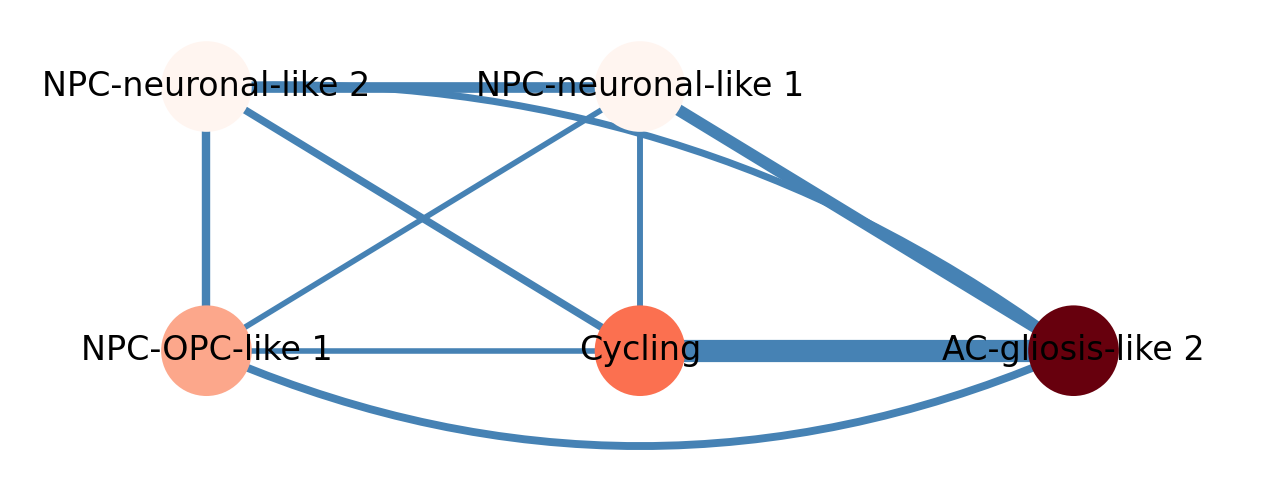

In [ ]:
distance_col = 'inv_distance'

G = nx.from_pandas_edgelist(
    df,
    source="clusterA",
    target="clusterB",
    edge_attr=distance_col,
    create_using=nx.Graph()
)

nx.set_edge_attributes(
    G,
    {(u, v): d[distance_col] for u, v, d in G.edges(data=True)},
    name="weight"
)

nodes = list(G.nodes())
if len(nodes) != 5:
    raise ValueError("This manual layout expects exactly 4 nodes.")

pos = {
    "NPC-neuronal-like 2": (0, 1),  # top-left
    "NPC-neuronal-like 1": (1, 1),  # top-right
    "NPC-OPC-like 1": (0, 0),  # bottom-left
    "Cycling": (1, 0),   # bottom-right
    "AC-gliosis-like 2": (2, 0)
}

# extract distances
distances = [d[distance_col] for _, _, d in G.edges(data=True)]


min_w, max_w = 2, 8   # change these

distances = [d["weight"] for _, _, d in G.edges(data=True)]

d_min, d_max = min(distances), max(distances)
widths = [
    min_w + (d - d_min) / (d_max - d_min) * (max_w - min_w)
    if d_max > d_min else min_w
    for d in distances
]

fig, ax = plt.subplots(figsize=(8, 3))

straight_edges, curved_edges = [], []
straight_widths, curved_widths = [], []
straight_colors, curved_colors = [], []

for (u, v, d), w in zip(G.edges(data=True), widths):
    col_gap = abs(pos[u][0] - pos[v][0])

    if col_gap == 2:   # exactly one column in between
        curved_edges.append((u, v))
        curved_widths.append(w)
        curved_colors.append(d["weight"])
    else:              # same column or adjacent column
        straight_edges.append((u, v))
        straight_widths.append(w)
        straight_colors.append(d["weight"])

node_colors = [latent_time[n] for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax, 
                       node_color=node_colors,
                       cmap=cm.Reds,
                       vmin = 0.5,
                       vmax = 1,
                       node_size=1000)
nx.draw_networkx_labels(G, pos, ax=ax)

nx.draw_networkx_edges(
    G,
    pos,
    ax=ax,
    edgelist=straight_edges,
    width=straight_widths,
    edge_color='steelblue',
    #edge_cmap=cm.Blues,
    #edge_vmin= 0, #min(distances),
    #edge_vmax=max(distances),
)

# draw curved edges one at a time
for (u, v), w, c in zip(curved_edges, curved_widths, curved_colors):
    y1 = pos[u][1]
    y2 = pos[v][1]

    if y1 == y2:
        rad = 0.22 if y1 > 0 else -0.22
    else:
        rad = 0.18

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edgelist=[(u, v)],
        width=[w],
        edge_color='steelblue',
        #edge_cmap=cm.Blues,
        #edge_vmin=0, #min(distances),
        #edge_vmax=max(distances),
        connectionstyle=f"arc3,rad={rad}",
        arrows=True,
        arrowstyle="-",
    )

ax.margins(0.15)
ax.set_axis_off()
plt.savefig(outdir+'AT15_4_network.pdf')

In [ ]:
df.drop(['min_max_dist','1-min_max_dist'], axis=1).reset_index(drop=True)\
    .to_csv('../../../data/EDFig8/EDFig8b1.csv')